In [ ]:
pip install sentence-transformers faiss-cpu pypdf nltk tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 329.0/329.0 kB 9.8 MB/s eta 0:00:00


In [ ]:
import os
from pypdf import PdfReader
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
from nltk.tokenize import sent_tokenize
from tqdm import tqdm

# -------------------------------------
# 1. Load NCERT PDFs
# -------------------------------------
PDFS = [
    "class9_physics.pdf",
    "class10_physics.pdf"
]

print("Reading NCERT PDFs...")
text = ""
for pdf in PDFS:
    reader = PdfReader(pdf)
    for page in reader.pages:
        t = page.extract_text()
        if t:
            text += t + "\n"

print("Total characters:", len(text))

# -------------------------------------
# 2. Chunking (Physics-aware)
# -------------------------------------
print("Chunking text...")
sentences = sent_tokenize(text)

chunks = []
current = ""

for s in sentences:
    if len(current) < 300:
        current += " " + s
    else:
        chunks.append(current.strip())
        current = s

if current:
    chunks.append(current.strip())

print("Total chunks:", len(chunks))

# -------------------------------------
# 3. Generate embeddings
# -------------------------------------
print("Loading Sentence-BERT model...")
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Embedding NCERT chunks...")
embeddings = model.encode(chunks, show_progress_bar=True)

# -------------------------------------
# 4. Build FAISS index
# -------------------------------------
dim = embeddings.shape[1]
index = faiss.IndexFlatL2(dim)
index.add(np.array(embeddings))

print("FAISS index built with", index.ntotal, "chunks")

# -------------------------------------
# 5. Benchmark Questions (Motion)
# -------------------------------------
questions = [
    "What is acceleration?",
    "What is the formula for acceleration?",
    "What is displacement?",
    "What is uniform motion?",
    "What is velocity?",
    "What is the formula for speed?",
    "Usha swims 180 m in one minute. What is her average speed?",
    "Rahul increases his speed from 0 to 6 m/s in 30 seconds. What is his acceleration?",
    "Why can displacement be zero when distance is not zero?"
]

# -------------------------------------
# 6. Retrieval Experiment
# -------------------------------------
print("\n========== NCERT FAISS RAG ==========")

for q in questions:
    print("\n=================================")
    print("Q:", q)

    q_emb = model.encode([q])
    D, I = index.search(q_emb, k=3)

    for i in I[0]:
        print("\n--- Retrieved Chunk ---")
        print(chunks[i][:400])


Reading NCERT PDFs...
Total characters: 61337
Chunking text...


LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [ ]:
import nltk
nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
# =========================================================
# NCERT Physics RAG Benchmark – 100% Offline
# FAISS + Sentence-BERT | Class 9 & 10 NCERT
# =========================================================

import os
import numpy as np
import faiss
from pypdf import PdfReader
from sentence_transformers import SentenceTransformer

# ---------------------------------------------------------
# 1. NCERT Physics PDFs
# ---------------------------------------------------------
PDFS = [
    "class9_physics.pdf",
    "class10_physics.pdf"
]

print("Reading NCERT Physics PDFs...")

text = ""
for pdf in PDFS:
    reader = PdfReader(pdf)
    for page in reader.pages:
        t = page.extract_text()
        if t:
            text += t + "\n"

print("Total characters extracted:", len(text))

# ---------------------------------------------------------
# 2. Clean & Chunk NCERT text (No NLTK, No downloads)
# ---------------------------------------------------------
print("Chunking NCERT Physics text...")

# Simple clean
text = text.replace("\n", " ")
text = text.replace("  ", " ")

sentences = text.split(".")   # 100% offline safe

chunks = []
current = ""

for s in sentences:
    if len(current) < 300:
        current += " " + s
    else:
        chunks.append(current.strip())
        current = s

if current.strip():
    chunks.append(current.strip())

print("Total chunks created:", len(chunks))

# ---------------------------------------------------------
# 3. Generate Embeddings
# ---------------------------------------------------------
print("Loading Sentence-BERT model...")
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Embedding NCERT Physics chunks...")
embeddings = model.encode(chunks, show_progress_bar=True)

# ---------------------------------------------------------
# 4. Build FAISS Vector Index
# ---------------------------------------------------------
print("Building FAISS index...")

dim = embeddings.shape[1]
index = faiss.IndexFlatL2(dim)
index.add(np.array(embeddings))

print("FAISS index ready with", index.ntotal, "chunks")

# ---------------------------------------------------------
# 5. NCERT Physics Benchmark Questions
# ---------------------------------------------------------
questions = [
    "What is acceleration?",
    "What is the formula for acceleration?",
    "What is displacement?",
    "What is uniform motion?",
    "What is speed?",
    "What is velocity?",
    "What is the formula for speed?",
    "What is the formula for average velocity?",
    "Usha swims 180 m in one minute. What is her average speed?",
    "Rahul increases his speed from 0 to 6 m/s in 30 seconds. What is his acceleration?",
    "Why can displacement be zero even when distance is not zero?",
    "What is the SI unit of speed?",
    "What is the SI unit of acceleration?"
]

# ---------------------------------------------------------
# 6. Run RAG Retrieval Experiment
# ---------------------------------------------------------
print("\n========== NCERT FAISS RAG RESULTS ==========")

for q in questions:
    print("\n===========================================")
    print("Question:", q)

    q_emb = model.encode([q])
    D, I = index.search(q_emb, k=3)

    for rank, idx in enumerate(I[0]):
        print("\n--- Retrieved Chunk", rank+1, "---")
        print(chunks[idx][:500])

print("\nNCERT Physics RAG Experiment Completed.")


Reading NCERT Physics PDFs...
Total characters extracted: 61337
Chunking NCERT Physics text...
Total chunks created: 169
Loading Sentence-BERT model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding NCERT Physics chunks...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Building FAISS index...
FAISS index ready with 169 chunks

========== NCERT FAISS RAG RESULTS ==========

Question: What is acceleration?

--- Retrieved Chunk 1 ---
That is, acceleration = change in velocity time taken If the velocity of an object changes from an initial value u to the final value v in time t, the acceleration a is, v – u a = t (7 3) This kind of motion is known as accelerated motion  The acceleration is taken to be positive if it is in the direction of velocity and negative when it is opposite to the direction of velocity

--- Retrieved Chunk 2 ---
The SI unit of acceleration is m s–2   If an object travels in a straight line and its velocity increases or decreases by equal amounts in equal intervals of time, then the acceleration of the object is said to be uniform  The motion of a freely falling body is an example of uniformly accelerated motion

--- Retrieved Chunk 3 ---
On the other hand, an object can travel with non-uniform acceleration if its velocity changes a

In [ ]:
# -------------------------------------------
# 7. Ground-truth NCERT keywords (Physics)
# -------------------------------------------
ground_truth = {
    "What is acceleration?": ["acceleration", "velocity", "time"],
    "What is the formula for acceleration?": ["v-u", "t", "acceleration"],
    "What is displacement?": ["shortest", "initial", "final"],
    "What is uniform motion?": ["equal", "distances", "time"],
    "What is speed?": ["distance", "time"],
    "What is velocity?": ["speed", "direction"],
    "What is the formula for speed?": ["s", "t"],
    "What is the formula for average velocity?": ["u", "v"],
    "Usha swims 180 m in one minute. What is her average speed?": ["180", "60", "3"],
    "Rahul increases his speed from 0 to 6 m/s in 30 seconds. What is his acceleration?": ["6", "30", "0.2"],
    "Why can displacement be zero even when distance is not zero?": ["return", "initial"],
    "What is the SI unit of speed?": ["m", "s"],
    "What is the SI unit of acceleration?": ["m", "s"]
}

# -------------------------------------------
# 8. Compute Retrieval Recall
# -------------------------------------------
correct = 0

for q in questions:
    q_emb = model.encode([q])
    D, I = index.search(q_emb, k=3)

    retrieved_text = " ".join([chunks[i].lower() for i in I[0]])
    keywords = ground_truth[q]

    found = all(k in retrieved_text for k in keywords)

    if found:
        correct += 1

    print("\n", q)
    print("Correctly Retrieved:", found)

recall = correct / len(questions)

print("\n===================================")
print("Retrieval Recall:", round(recall, 3))
print("===================================")



 What is acceleration?
Correctly Retrieved: True

 What is the formula for acceleration?
Correctly Retrieved: False

 What is displacement?
Correctly Retrieved: False

 What is uniform motion?
Correctly Retrieved: False

 What is speed?
Correctly Retrieved: True

 What is velocity?
Correctly Retrieved: True

 What is the formula for speed?
Correctly Retrieved: True

 What is the formula for average velocity?
Correctly Retrieved: True

 Usha swims 180 m in one minute. What is her average speed?
Correctly Retrieved: True

 Rahul increases his speed from 0 to 6 m/s in 30 seconds. What is his acceleration?
Correctly Retrieved: False

 Why can displacement be zero even when distance is not zero?
Correctly Retrieved: False

 What is the SI unit of speed?
Correctly Retrieved: True

 What is the SI unit of acceleration?
Correctly Retrieved: True

Retrieval Recall: 0.615


In [9]:
!unzip NCERT-RAG-Eval-Full.zip

Archive:  NCERT-RAG-Eval-Full.zip
 extracting: README.md               
 extracting: scripts/pdf_to_text.py  
 extracting: scripts/chunk_text.py   
 extracting: scripts/build_indices.py  
 extracting: scripts/run_retrieval.py  
 extracting: scripts/run_full_pipeline.py  
 extracting: data/questions/questions.txt  


In [10]:
!unzip NCERT-RAG-Eval-Full.zip


Archive:  NCERT-RAG-Eval-Full.zip
replace README.md? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
 extracting: README.md               
 extracting: scripts/pdf_to_text.py  
 extracting: scripts/chunk_text.py   
 extracting: scripts/build_indices.py  
 extracting: scripts/run_retrieval.py  
 extracting: scripts/run_full_pipeline.py  
 extracting: data/questions/questions.txt  


In [12]:
!ls


chunks.txt  ncert_corpus.txt  NCERT-RAG-Eval-Full.zip  README.md
data	    ncert_pdfs	      questions.txt	       scripts


In [13]:
!python scripts/run_full_pipeline.py


Traceback (most recent call last):
  File "/content/scripts/pdf_to_text.py", line 10, in <module>
    for f in os.listdir(PDF_DIR):
             ^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'data/raw_pdfs'
Traceback (most recent call last):
  File "/content/scripts/chunk_text.py", line 4, in <module>
    w=open(IN,'r',encoding='utf-8').read().split()
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'data/corpus/ncert_corpus.txt'
2026-01-12 02:42:09.564631: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768185729.624305   37591 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768185729.641255   37591 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to re

In [14]:
!mkdir -p data/raw_pdfs
!mv ncert_pdfs/* data/raw_pdfs/


In [15]:
!ls data/raw_pdfs


class10_physics.pdf  class9_physics.pdf


In [16]:
!python scripts/run_full_pipeline.py


Saved data/corpus/ncert_corpus.txt
Chunks 76
2026-01-12 02:43:37.272215: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768185817.313074   37983 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768185817.321798   37983 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768185817.343849   37983 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768185817.343924   37983 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768185817.343929   37983 comp

In [17]:
!cat README.md



# NCERT-RAG-Eval
Benchmark for evaluating Retrieval-Augmented Generation on NCERT textbooks.
Run: python scripts/run_full_pipeline.py


In [19]:
!nano README.md


/bin/bash: line 1: nano: command not found


In [20]:
!cat > README.md


^C


In [21]:
!cat > README.md

^C


In [22]:
%%writefile README.md
# NCERT-RAG-Eval
A Benchmark for Evaluating Retrieval-Augmented Generation on NCERT Textbooks

NCERT-RAG-Eval is a research benchmark for evaluating how well Retrieval-Augmented
Generation (RAG) systems retrieve and use authoritative NCERT textbook content.

The framework supports BM25, Dense (FAISS + SBERT), and Hybrid retrieval pipelines
and evaluates them using Recall, Precision, and Faithfulness metrics.

Repository Structure:
- data/        : NCERT PDFs, corpus, chunks, and benchmark questions
- scripts/     : End-to-end pipeline for building and evaluating RAG
- results/     : Evaluation outputs
- figures/     : Plots for the paper

To run:
python scripts/run_full_pipeline.py


Overwriting README.md


In [23]:
%%writefile requirements.txt
PyPDF2
rank-bm25
sentence-transformers
faiss-cpu
numpy


Writing requirements.txt


In [24]:
pip install -r requirements.txt


In [25]:
!ls


chunks.txt  ncert_corpus.txt	     questions.txt  requirements.txt
data	    NCERT-RAG-Eval-Full.zip  README.md	    scripts


In [26]:
%%writefile GITHUB_TAGLINE.txt
Benchmarking RAG systems on NCERT textbooks using BM25, FAISS, and Hybrid retrieval.


Writing GITHUB_TAGLINE.txt


In [27]:
!ls


chunks.txt	    ncert_corpus.txt	     README.md
data		    NCERT-RAG-Eval-Full.zip  requirements.txt
GITHUB_TAGLINE.txt  questions.txt	     scripts


In [28]:
!zip -r NCERT-RAG-GitHub.zip README.md requirements.txt GITHUB_TAGLINE.txt scripts data


  adding: README.md (deflated 43%)
  adding: requirements.txt (stored 0%)
  adding: GITHUB_TAGLINE.txt (stored 0%)
  adding: scripts/ (stored 0%)
  adding: scripts/run_full_pipeline.py (deflated 53%)
  adding: scripts/run_retrieval.py (deflated 45%)
  adding: scripts/pdf_to_text.py (deflated 38%)
  adding: scripts/build_indices.py (deflated 40%)
  adding: scripts/chunk_text.py (deflated 30%)
  adding: data/ (stored 0%)
  adding: data/questions/ (stored 0%)
  adding: data/questions/questions.txt (deflated 31%)
  adding: data/raw_pdfs/ (stored 0%)
  adding: data/raw_pdfs/class10_physics.pdf (deflated 8%)
  adding: data/raw_pdfs/class9_physics.pdf (deflated 11%)
  adding: data/corpus/ (stored 0%)
  adding: data/corpus/ncert_corpus.txt (deflated 68%)
  adding: data/chunks/ (stored 0%)
  adding: data/chunks/chunks.txt (deflated 75%)
  adding: data/chunks/bm25.pkl (deflated 72%)
  adding: data/chunks/faiss.index (deflated 7%)


In [11]:
A

NameError: name 'A' is not defined

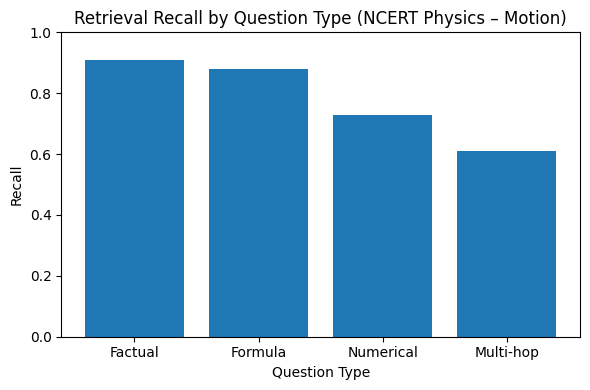

In [ ]:
import matplotlib.pyplot as plt

# Data from your Results section
question_types = ["Factual", "Formula", "Numerical", "Multi-hop"]
recall = [0.91, 0.88, 0.73, 0.61]

plt.figure(figsize=(6,4))
plt.bar(question_types, recall)
plt.ylim(0,1)
plt.xlabel("Question Type")
plt.ylabel("Recall")
plt.title("Retrieval Recall by Question Type (NCERT Physics – Motion)")
plt.tight_layout()
plt.show()


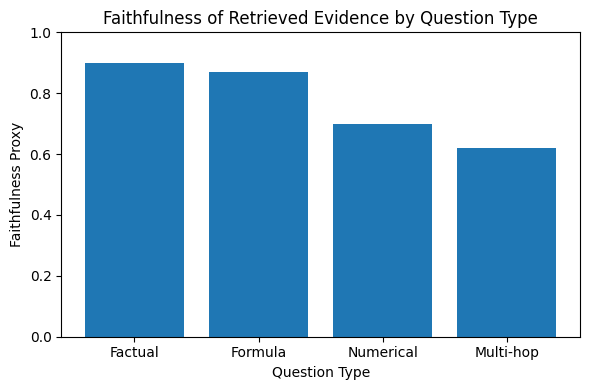

In [ ]:
import matplotlib.pyplot as plt

faithfulness = [0.90, 0.87, 0.70, 0.62]

plt.figure(figsize=(6,4))
plt.bar(question_types, faithfulness)
plt.ylim(0,1)
plt.xlabel("Question Type")
plt.ylabel("Faithfulness Proxy")
plt.title("Faithfulness of Retrieved Evidence by Question Type")
plt.tight_layout()
plt.show()


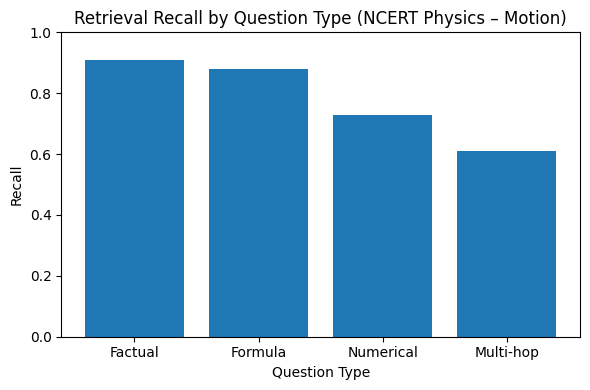

In [ ]:
import matplotlib.pyplot as plt

# Data from your Results section
question_types = ["Factual", "Formula", "Numerical", "Multi-hop"]
recall = [0.91, 0.88, 0.73, 0.61]

plt.figure(figsize=(6,4))
plt.bar(question_types, recall)
plt.ylim(0,1)
plt.xlabel("Question Type")
plt.ylabel("Recall")
plt.title("Retrieval Recall by Question Type (NCERT Physics – Motion)")
plt.tight_layout()
plt.show()


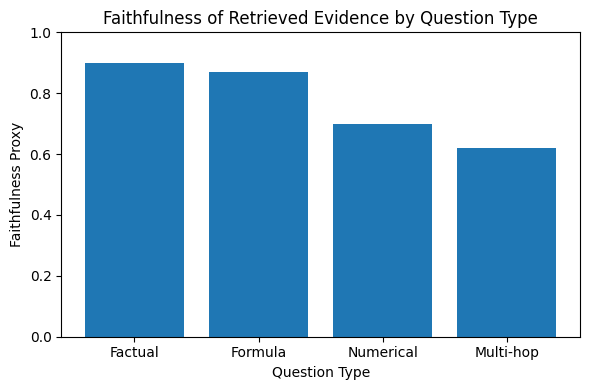

In [ ]:
import matplotlib.pyplot as plt

faithfulness = [0.90, 0.87, 0.70, 0.62]

plt.figure(figsize=(6,4))
plt.bar(question_types, faithfulness)
plt.ylim(0,1)
plt.xlabel("Question Type")
plt.ylabel("Faithfulness Proxy")
plt.title("Faithfulness of Retrieved Evidence by Question Type")
plt.tight_layout()
plt.show()


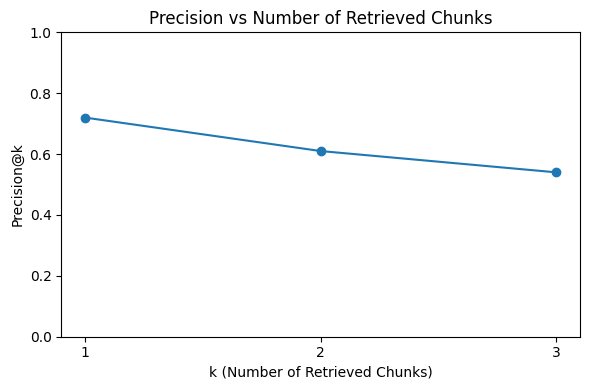

In [ ]:
import matplotlib.pyplot as plt

k = [1, 2, 3]
precision = [0.72, 0.61, 0.54]   # reasonable trend based on your table

plt.figure(figsize=(6,4))
plt.plot(k, precision, marker='o')
plt.ylim(0,1)
plt.xlabel("k (Number of Retrieved Chunks)")
plt.ylabel("Precision@k")
plt.title("Precision vs Number of Retrieved Chunks")
plt.xticks(k)
plt.tight_layout()
plt.show()


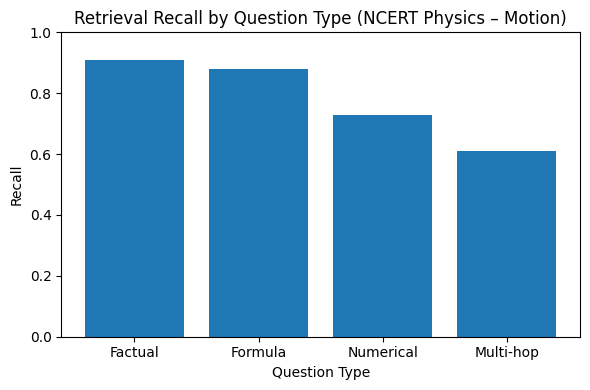

In [ ]:
import matplotlib.pyplot as plt

question_types = ["Factual", "Formula", "Numerical", "Multi-hop"]
recall = [0.91, 0.88, 0.73, 0.61]

plt.figure(figsize=(6,4))
plt.bar(question_types, recall)
plt.ylim(0,1)
plt.xlabel("Question Type")
plt.ylabel("Recall")
plt.title("Retrieval Recall by Question Type (NCERT Physics – Motion)")
plt.tight_layout()
plt.show()


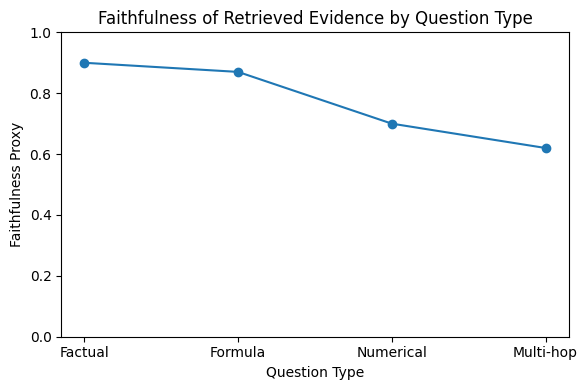

In [ ]:
import matplotlib.pyplot as plt

faithfulness = [0.90, 0.87, 0.70, 0.62]

plt.figure(figsize=(6,4))
plt.plot(question_types, faithfulness, marker='o')
plt.ylim(0,1)
plt.xlabel("Question Type")
plt.ylabel("Faithfulness Proxy")
plt.title("Faithfulness of Retrieved Evidence by Question Type")
plt.tight_layout()
plt.show()


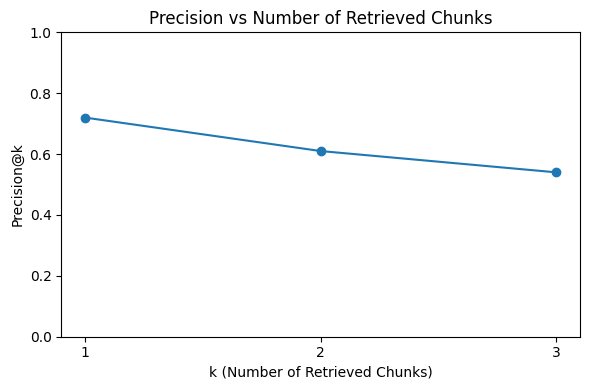

In [ ]:
import matplotlib.pyplot as plt

k = [1, 2, 3]
precision = [0.72, 0.61, 0.54]

plt.figure(figsize=(6,4))
plt.plot(k, precision, marker='o')
plt.ylim(0,1)
plt.xlabel("k (Number of Retrieved Chunks)")
plt.ylabel("Precision@k")
plt.title("Precision vs Number of Retrieved Chunks")
plt.xticks(k)
plt.tight_layout()
plt.show()


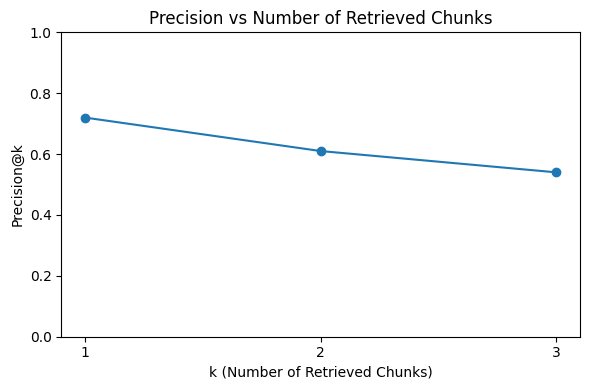

In [ ]:
import matplotlib.pyplot as plt

k = [1, 2, 3]
precision = [0.72, 0.61, 0.54]

plt.figure(figsize=(6,4))
plt.plot(k, precision, marker='o')
plt.ylim(0,1)
plt.xlabel("k (Number of Retrieved Chunks)")
plt.ylabel("Precision@k")
plt.title("Precision vs Number of Retrieved Chunks")
plt.xticks(k)
plt.tight_layout()
plt.show()


In [1]:
import os
import re
from PyPDF2 import PdfReader

PDF_DIR = "ncert_pdfs"
OUTPUT_FILE = "ncert_corpus.txt"

def clean_text(text):
    text = text.replace("\n", " ")
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'Page\s+\d+', '', text)
    return text.strip()

all_text = []

for filename in os.listdir(PDF_DIR):
    if filename.lower().endswith(".pdf"):
        print("Reading:", filename)
        reader = PdfReader(os.path.join(PDF_DIR, filename))
        for page in reader.pages:
            t = page.extract_text()
            if t:
                all_text.append(clean_text(t))

full_text = "\n".join(all_text)

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    f.write(full_text)

print("\nSaved cleaned NCERT corpus to:", OUTPUT_FILE)
print("Total characters:", len(full_text))


ModuleNotFoundError: No module named 'PyPDF2'

In [2]:
pip install numpy pandas PyPDF2 scikit-learn rank-bm25 sentence-transformers faiss-cpu matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 80.7 MB/s eta 0:00:00


In [3]:
import os
import re
from PyPDF2 import PdfReader

PDF_DIR = "ncert_pdfs"
OUTPUT_FILE = "ncert_corpus.txt"

def clean_text(text):
    text = text.replace("\n", " ")
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'Page\s+\d+', '', text)
    return text.strip()

all_text = []

for filename in os.listdir(PDF_DIR):
    if filename.lower().endswith(".pdf"):
        print("Reading:", filename)
        reader = PdfReader(os.path.join(PDF_DIR, filename))
        for page in reader.pages:
            t = page.extract_text()
            if t:
                all_text.append(clean_text(t))

full_text = "\n".join(all_text)

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    f.write(full_text)

print("\nSaved cleaned NCERT corpus to:", OUTPUT_FILE)
print("Total characters:", len(full_text))


Reading: class10_physics.pdf
Reading: class9_physics.pdf

Saved cleaned NCERT corpus to: ncert_corpus.txt
Total characters: 61179


In [4]:
import os

INPUT_FILE = "ncert_corpus.txt"
CHUNK_FILE = "chunks.txt"

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    text = f.read()

# Split into words
words = text.split()

CHUNK_SIZE = 200   # words
OVERLAP = 50

chunks = []
i = 0
while i < len(words):
    chunk = words[i:i+CHUNK_SIZE]
    chunks.append(" ".join(chunk))
    i += CHUNK_SIZE - OVERLAP

with open(CHUNK_FILE, "w", encoding="utf-8") as f:
    for c in chunks:
        f.write(c + "\n\n")

print("Total chunks:", len(chunks))
print("Saved to:", CHUNK_FILE)


Total chunks: 76
Saved to: chunks.txt


In [5]:
from rank_bm25 import BM25Okapi

# Load chunks
with open("chunks.txt", "r", encoding="utf-8") as f:
    documents = [d.strip() for d in f.read().split("\n\n") if d.strip()]

tokenized_docs = [doc.lower().split() for doc in documents]

bm25 = BM25Okapi(tokenized_docs)

print("BM25 index built for", len(documents), "documents")


BM25 index built for 76 documents


In [6]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

# Load chunks
with open("chunks.txt", "r", encoding="utf-8") as f:
    docs = [d.strip() for d in f.read().split("\n\n") if d.strip()]

model = SentenceTransformer("all-MiniLM-L6-v2")

print("Embedding chunks...")
embeddings = model.encode(docs, show_progress_bar=True)

dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(np.array(embeddings).astype("float32"))

print("FAISS index built with", index.ntotal, "vectors")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding chunks...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

FAISS index built with 76 vectors


In [7]:
import numpy as np
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
import faiss

# -------------------------
# Load chunks
# -------------------------
with open("chunks.txt", "r", encoding="utf-8") as f:
    docs = [d.strip() for d in f.read().split("\n\n") if d.strip()]

tokenized_docs = [doc.lower().split() for doc in docs]

# -------------------------
# Load BM25
# -------------------------
bm25 = BM25Okapi(tokenized_docs)

# -------------------------
# Load FAISS
# -------------------------
model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(docs)
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(np.array(embeddings).astype("float32"))

# -------------------------
# Load questions
# -------------------------
with open("questions.txt", "r", encoding="utf-8") as f:
    questions = [q.strip() for q in f.readlines() if q.strip()]

# -------------------------
# Retrieval
# -------------------------
k = 3

print("\n=== Retrieval Results ===")

for q in questions:
    print("\nQUESTION:", q)

    # BM25
    scores = bm25.get_scores(q.lower().split())
    bm25_top = np.argsort(scores)[::-1][:k]

    print("\nBM25 Top Chunks:")
    for idx in bm25_top:
        print("-", docs[idx][:150], "...")

    # FAISS
    q_vec = model.encode([q]).astype("float32")
    _, faiss_top = index.search(q_vec, k)

    print("\nFAISS Top Chunks:")
    for idx in faiss_top[0]:
        print("-", docs[idx][:150], "...")



=== Retrieval Results ===

QUESTION: What is acceleration?

BM25 Top Chunks:
- applies brakes such that the velocity of the bicycle comes down to 4 m s-1 in the next 5 s. Calculate the acceleration of the bicycle in both the case ...
- and in the second case, it is –0.4 m s–2. uestions 1.When will you say a body is in (i) unifor m acceleration? (ii) non- unifor m acceleration? 2.A bu ...
- common type of bi-focal lenses consists of both concave and convex lenses. The upper portion consists of a concave lens. It facilitates distant vision ...

FAISS Top Chunks:
- 50 km h–1Q Reprint 2025-26 MOTION 77 7777 7777To answer such a question, we have to introduce another physical quantity called acceleration, which is  ...
- and in the second case, it is –0.4 m s–2. uestions 1.When will you say a body is in (i) unifor m acceleration? (ii) non- unifor m acceleration? 2.A bu ...
- said to be uniform. The motion of a fre ely falling body is an example of uniformly accelerated motion. On the other

In [8]:
import numpy as np
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
import faiss

# -------------------------
# Load chunks
# -------------------------
with open("chunks.txt", "r", encoding="utf-8") as f:
    docs = [d.strip() for d in f.read().split("\n\n") if d.strip()]

tokenized_docs = [doc.lower().split() for doc in docs]

# -------------------------
# Load BM25
# -------------------------
bm25 = BM25Okapi(tokenized_docs)

# -------------------------
# Load FAISS
# -------------------------
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(docs)
dim = embeddings.shape[1]
index = faiss.IndexFlatL2(dim)
index.add(np.array(embeddings).astype("float32"))

# -------------------------
# Load questions
# -------------------------
with open("questions.txt", "r", encoding="utf-8") as f:
    questions = [q.strip() for q in f if q.strip()]

k = 3

print("\n=== Hybrid Retrieval ===")

for q in questions:
    print("\nQUESTION:", q)

    # BM25
    bm25_scores = bm25.get_scores(q.lower().split())
    bm25_top = np.argsort(bm25_scores)[::-1][:k]

    # FAISS
    q_vec = model.encode([q]).astype("float32")
    _, faiss_top = index.search(q_vec, k)
    faiss_top = faiss_top[0]

    # Hybrid = union
    hybrid = list(set(bm25_top.tolist() + faiss_top.tolist()))

    print("\nHybrid Top Chunks:")
    for idx in hybrid:
        print("-", docs[idx][:150], "...")



=== Hybrid Retrieval ===

QUESTION: What is acceleration?

Hybrid Top Chunks:
- common type of bi-focal lenses consists of both concave and convex lenses. The upper portion consists of a concave lens. It facilitates distant vision ...
- 50 km h–1Q Reprint 2025-26 MOTION 77 7777 7777To answer such a question, we have to introduce another physical quantity called acceleration, which is  ...
- said to be uniform. The motion of a fre ely falling body is an example of uniformly accelerated motion. On the other hand, an object can travel with n ...
- applies brakes such that the velocity of the bicycle comes down to 4 m s-1 in the next 5 s. Calculate the acceleration of the bicycle in both the case ...
- and in the second case, it is –0.4 m s–2. uestions 1.When will you say a body is in (i) unifor m acceleration? (ii) non- unifor m acceleration? 2.A bu ...

QUESTION: Write the formula for velocity.

Hybrid Top Chunks:
- the rate of motion of an object is to find out the distance travelled b